# Notebook 02 - Text Preprocessing and Topic Modelling

Preprocesses the full Reddit corpus, applies LDA topic modelling to identify the greenwashing-dominant topic, and runs a second-level LDA on the greenwashing subset to map internal sub-topics.

**Input:** `../data/processed/greenwashing_dataset_filtered.csv`  
**Output:** `../data/processed/df_greenwashing_topic1.csv`

In [9]:
import pandas as pd
import numpy as np
import re
import gc  # manual garbage collection for large corpus processing
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)

In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# download required NLTK packages (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /Users/giuly/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/giuly/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/giuly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/giuly/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/giuly/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

## 1. Data Loading

In [12]:
df = pd.read_csv('../data/processed/greenwashing_dataset_filtered.csv', parse_dates=['Timestamp'])

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nContent types:\n{df['content_type'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTimestamp range: {df['Timestamp'].min()} → {df['Timestamp'].max()}")
df.sample(5)

Shape: (27851, 8)

Columns: ['Post_id', 'Timestamp', 'Text', 'Score', 'subreddit', 'content_type', 'text_length', 'year']

Content types:
content_type
comment    27008
post         843
Name: count, dtype: int64

Missing values:
Post_id         0
Timestamp       0
Text            0
Score           0
subreddit       0
content_type    0
text_length     0
year            0
dtype: int64

Timestamp range: 2010-05-18 21:16:00 → 2025-04-01 05:43:00


,Post_id,Timestamp,Text,Score,subreddit,content_type,text_length,year
8196,143hhk9,2023-06-07 23:59:00,"Hydrogen by product is oxygen and when burn, its water. I dont see why you think its green washing?",1.0,sustainabilitySubreddit,comment,99,2023
13300,13ssoar,2023-05-27 12:57:00,I'm not as radical as some of you guys but I hate littering.,2.0,AnticonsumptionSubreddit,comment,60,2023
22573,n16imn,2021-04-30 07:32:00,"Rebel sport, just check if you local one has a bin.",2.0,ZeroWasteSubreddit,comment,51,2021
17367,1hv0qok,2025-01-06 19:10:00,What exactly is evil about an exclusivity agreement? Both sides benefit. It's a standard business deal.,-7.0,AnticonsumptionSubreddit,comment,103,2025
1147,49nz2i,2016-03-10 18:34:00,"Damn it, people! Stop throwing away your glass!! >.<",1.0,environmentSubreddit,comment,52,2016


## 2. Text Preprocessing

Pipeline applied to each document:
1. Lowercase
2. Remove punctuation and special characters
3. Tokenize
4. Remove stopwords (NLTK English list + custom extensions)
5. Lemmatize

Two passes are run: a first with the standard NLTK stopword list to generate an initial wordcloud, then a second with an extended list after inspecting which high-frequency words carry no thematic signal.

In [13]:
def preprocess_text(text):
    if pd.isna(text):
        return ''
    # 1. lowercase
    text = text.lower()
    # 2. remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. tokenize
    tokens = word_tokenize(text)
    # 4. remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # 5. lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [14]:
print("Preprocessing...")
df['text_clean'] = df['Text'].apply(preprocess_text)

# quick sanity check
print(f"Done. Empty texts after preprocessing: {(df['text_clean'] == '').sum()}")
df[['Text', 'text_clean']].sample(3)

Preprocessing...
Done. Empty texts after preprocessing: 2


,Text,text_clean
8945,"I would say define technology. In my view, technology are those skills possessed by human beings that are embodied within an exterior physical form. \n\nThis is a broad definition, including the use of power plants, radio transmitters and waves, and x-ray crystallography. However this definition also includes the use of organic farming techniques of saving and harvesting seeds, collecting rainwater, and raising fish.\n\nSome technologies uphold nature and can help restore ecosystems, such as water harvesting ponds and earthworks, while some technology destroys nature, some tech purposefully (bulldozers, chainsaws) and other tech passively (fossil fuel burning, creating pollution). \nIt's up to humanity to interpret our own talents and guide our actions in a nature affirming way.",would say define technology view technology skill possessed human being embodied within exterior physical form broad definition including use power plant radio transmitter wave xray crystallography however definition also includes use organic farming technique saving harvesting seed collecting rainwater raising fish technology uphold nature help restore ecosystem water harvesting pond earthwork technology destroys nature tech purposefully bulldozer chainsaw tech passively fossil fuel burning creating pollution humanity interpret talent guide action nature affirming way
25271,Let's protect our nature for the future. \nSupport innovative projects that really matter. We will achieve Net-Zero! \n\n\nLeafPays is one of the blockchain projects that leverage NFTs to lower emissions. \nLearn more about this in - \nWebsite: [https://www.leafpays.com/](https://www.leafpays.com/) \nDiscord: https://discord.gg/A28EWFcn,let protect nature future support innovative project really matter achieve netzero leafpays one blockchain project leverage nfts lower emission learn website httpswwwleafpayscomhttpswwwleafpayscom discord httpsdiscordggaewfcn
14733,"In my country they re not scared to call you names for not using plastic bags too, yeah i hate it.",country scared call name using plastic bag yeah hate


In [15]:
df = df[df['text_clean'] != '']
print(f"Shape after dropping empty texts: {df.shape}")

Shape after dropping empty texts: (27849, 9)


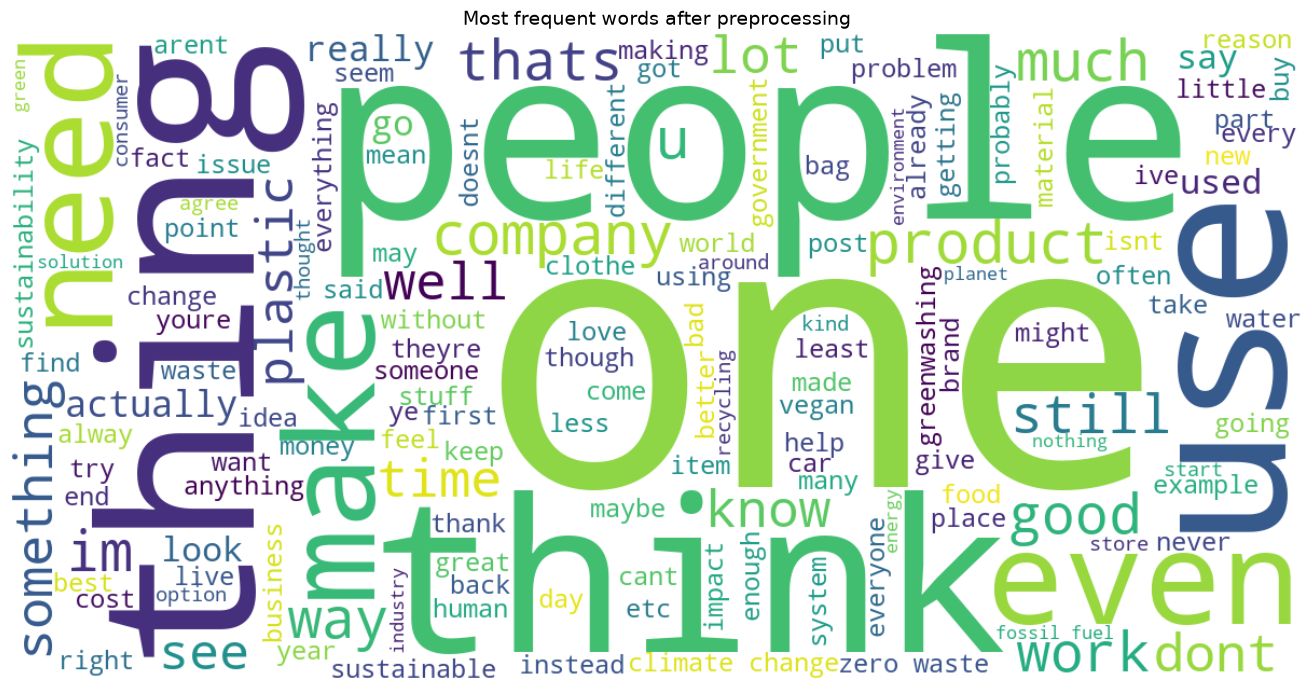

In [16]:
from wordcloud import WordCloud

text_all = ' '.join(df['text_clean'])

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(text_all)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words after preprocessing', fontsize=14)
plt.tight_layout()
plt.show()

## Custom Stopwords Extension

The initial wordcloud revealed a large number of high-frequency words 
that carry no thematic signal for this analysis: generic Reddit discourse 
markers (e.g. *people*, *think*, *thing*), informal contractions (*dont*, 
*isnt*, *cant*), intensifiers (*really*, *much*, *lot*) and generic verbs 
(*make*, *use*, *go*, *come*).

These words dominate the frequency distribution but contribute no useful 
information for topic modeling. They were added to the standard NLTK English 
stopword list before reapplying preprocessing.

In [17]:
custom_stopwords = {
    'people', 'one', 'think', 'thing', 'use', 'make', 'way', 'even',
    'dont', 'thats', 'isnt', 'doesnt', 'cant', 'im', 'youre', 'theyre', 'arent',
    'u', 'ye', 'etc', 'really', 'still', 'much', 'many', 'lot', 'well',
    'good', 'great', 'better', 'got', 'put', 'go', 'come', 'take', 'try',
    'say', 'feel', 'mean', 'seem', 'look', 'start', 'end', 'keep', 'would',
    'want', 'need', 'know', 'help', 'find', 'work', 'used', 'using',
    'something', 'anything', 'everything', 'nothing', 'someone', 'like', 'get',
    'also', 'back', 'around', 'first', 'every', 'never', 'always',
    'maybe', 'probably', 'though', 'already', 'enough', 'little',   'thing',
    'stuff', 'see', 'go', 'going', 'come', 'sure', 'actually', 'u', 'co',
    'right', 'yes', 'yeah', 'u', 'me', 'said', 'saying', 'didnt', 'wont',
    'thing', 'things', 'ive', 'u', 'time', 'point', 'thank', 'come', 'making'
}

stop_words_extended = stop_words | custom_stopwords

In [18]:
def preprocess_text_extendedstopwords(text):
    if pd.isna(text):
        return ''
    # 1. lowercase
    text = text.lower()
    # 2. remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. tokenize
    tokens = word_tokenize(text)
    # 4. remove stopwords
    tokens = [t for t in tokens if t not in stop_words_extended]
    # 5. lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [19]:
df['text_clean'] = df['Text'].apply(preprocess_text_extendedstopwords)
df[['Text', 'text_clean']].sample(3)

,Text,text_clean
265,"Has anyone tried Moonshot crackers? I think they taste great but apparently they’re also climate-conscious? Looking for someone to validate what that means / confirm a cracker can actually be good for the planet, lol. Sounds like this could be a case of greenwashing if you ask me.",anyone tried moonshot cracker taste apparently climateconscious looking validate mean confirm cracker planet lol sound could case greenwashing ask
12934,"Do you have an example of those articles? I'd like to read them. Or maybe if you just remember the publication or author, I could try to find them.\n\nI'm not sure about your idea that controlling population is easier than controlling consumption. After all, consider how much consumption varies across the world even today. Even within the same country, urban living produces about 8% less than suburban adjusting for other factors. This implies that eliminating the suburbs would allow an additional 700 million without increasing carbon emissions.\n\nIf you believe that technology and lifestyle changes are the key to sustainability, then logically you should support population growth. Technological growth increases more quickly than population (meaning that doubling population more than doubles innovation)\n\n(There's obviously other ways to measure consumption than carbon emissions, but its the most fungible)[https://theconversation.com/suburban-living-the-worst-for-carbon-emissions-new-research-149332](https://theconversation.com/suburban-living-the-worst-for-carbon-emissions-new-research-149332)(Measuring 'innovation' is going to be pretty vague no matter what, but hopefully you get what's meant by the idea)[https://royalsocietypublishing.org/doi/10.1098/rstb.2016.0415](https://royalsocietypublishing.org/doi/10.1098/rstb.2016.0415) \n\n\nEdit: I also think it's odd that you seem to believe that competition over resources is new. \n Resources are becoming competitive across all areas of the world (jobs, shelter, food, clean water) \nDid people not previously compete for resources? What could you mean by 'becoming competitive' here?",example article id read remember publication author could idea controlling population easier controlling consumption consider consumption varies across world today within country urban living produce less suburban adjusting factor implies eliminating suburb allow additional million without increasing carbon emission believe technology lifestyle change key sustainability logically support population growth technological growth increase quickly population meaning doubling population double innovation there obviously way measure consumption carbon emission fungiblehttpstheconversationcomsuburbanlivingtheworstforcarbonemissionsnewresearchhttpstheconversationcomsuburbanlivingtheworstforcarbonemissionsnewresearchmeasuring innovation pretty vague matter hopefully whats meant ideahttpsroyalsocietypublishingorgdoirstbhttpsroyalsocietypublishingorgdoirstb edit odd believe competition resource new resource becoming competitive across area world job shelter food clean water previously compete resource could becoming competitive
12914,Does anyone want to get fired? No one is more fragile than management in corporate America. Can’t handle any criticism.,anyone fired fragile management corporate america handle criticism


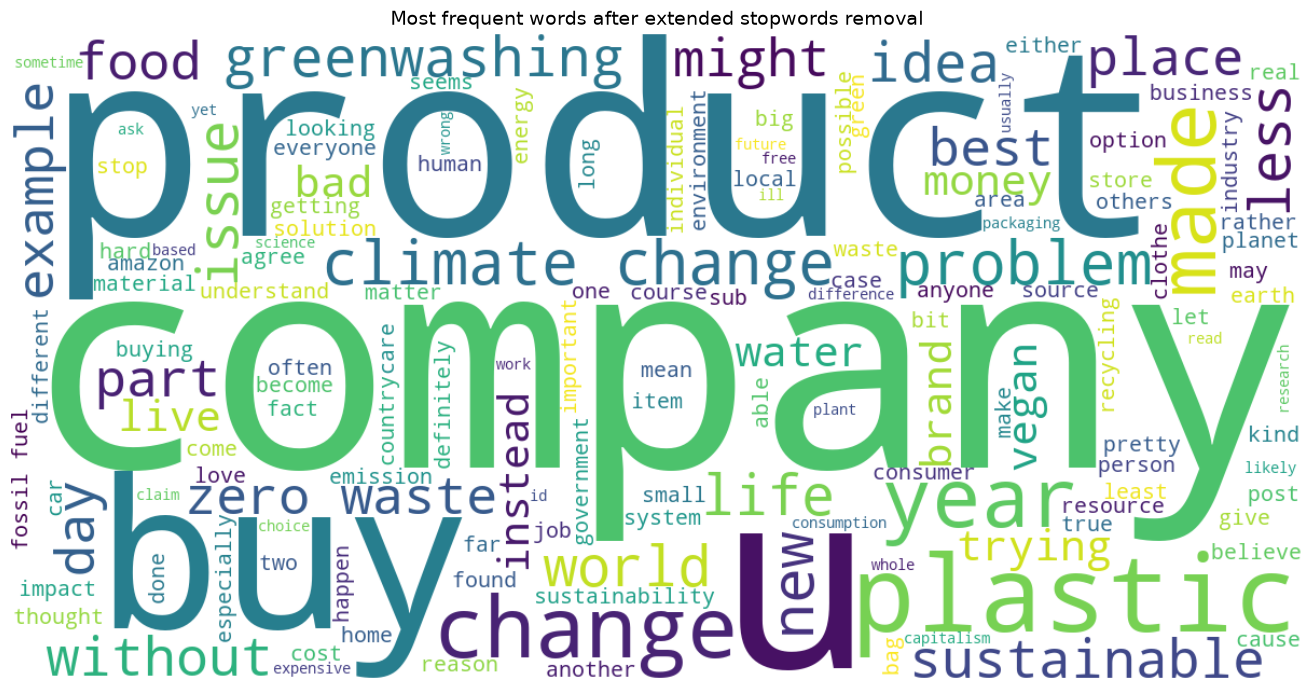

In [20]:
text_all = ' '.join(df['text_clean'])

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(text_all)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words after extended stopwords removal', fontsize=14)
plt.tight_layout()
plt.show()

## 3. LDA Topic Modelling

LDA (Latent Dirichlet Allocation) is run with n=5, 6, and 7 topics to find the most interpretable structure. Each trial is evaluated qualitatively by inspecting the top 15 words per topic.

Coherence scores (gensim c_v) were computed on Google Colab due to Python 3.14 compatibility issues with gensim locally. Results are documented in the markdown cells below.

In [21]:
# CountVectorizer converts text into a matrix of word counts
# Each row = one document (post or comment)
# Each column = one word in the vocabulary
# The value in each cell = how many times that word appears in that document

vectorizer = CountVectorizer(
    max_features=5000,  # keep only the 5000 most frequent words (RAM friendly)
    min_df=5,           # ignore words that appear in fewer than 5 documents (too rare to be meaningful)
    max_df=0.95         # ignore words that appear in more than 95% of documents (too common to be meaningful)
)

# fit_transform learns the vocabulary AND transforms the text in one step
dtm = vectorizer.fit_transform(df['text_clean'])

print(f"Document-term matrix shape: {dtm.shape}")
# expected: (27849, something ≤ 5000)

Document-term matrix shape: (27849, 5000)


In [22]:
# LDA - Latent Dirichlet Allocation
# n_components = number of topics we ask LDA to find
# We start with 5 topics - we can adjust after seeing the results
# random_state = 42 for reproducibility
# n_jobs = 1 to avoid memory issues on 8GB RAM

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    n_jobs=1
)

# fit LDA on the document-term matrix
# this is the slow step - may take a few minutes
lda.fit(dtm)

print("Done!")

Done!


In [23]:
# show top 15 words for each topic
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: company | carbon | energy | emission | fuel | sustainable | sustainability | greenwashing | green | business | product | fossil | power | cost | industry

Topic 2: plastic | bag | waste | product | water | recycling | bottle | packaging | reusable | year | recycled | container | oil | soap | paper

Topic 3: climate | change | year | science | post | comment | question | read | scientist | please | warming | earth | evidence | temperature | human

Topic 4: change | world | problem | food | life | car | meat | animal | live | vegan | individual | government | human | less | could

Topic 5: buy | product | waste | buying | brand | clothes | new | amazon | year | store | zero | item | made | fashion | clothing


In [24]:
# n=6 trial
lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    n_jobs=1
)

lda.fit(dtm)

print("Done!")

Done!


In [25]:
# show top 15 words for each topic
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: company | energy | product | sustainable | business | greenwashing | sustainability | green | cost | material | consumer | power | nuclear | fuel | tree

Topic 2: plastic | bag | waste | product | water | bottle | recycling | packaging | reusable | container | recycled | oil | buy | soap | year

Topic 3: year | change | thanks | climate | post | book | could | thought | human | believe | day | read | might | school | science

Topic 4: change | food | problem | world | car | life | meat | animal | individual | vegan | government | live | less | consumption | impact

Topic 5: buy | clothes | buying | waste | new | store | year | amazon | item | product | zero | brand | made | fashion | vegan

Topic 6: climate | change | carbon | year | emission | science | global | question | action | warming | comment | please | earth | scientist | temperature


In [26]:
# n=7 trial
lda = LatentDirichletAllocation(
    n_components=7,
    random_state=42,
    n_jobs=1
)

lda.fit(dtm)

print("Done!")

Done!


In [27]:
# show top 15 words for each topic
feature_names = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: company | energy | product | sustainable | business | sustainability | greenwashing | green | cost | power | fuel | consumer | nuclear | industry | environmental

Topic 2: water | tree | oil | soap | product | year | bottle | bar | buy | food | store | skin | container | laundry | wash

Topic 3: amazon | year | thanks | post | book | day | thought | could | change | friend | might | school | oh | ago | place

Topic 4: change | world | problem | food | life | meat | animal | car | individual | government | vegan | consumption | live | human | impact

Topic 5: buy | waste | clothes | buying | new | zero | product | item | store | vegan | brand | fashion | year | clothing | made

Topic 6: climate | change | carbon | year | science | question | emission | global | scientist | comment | warming | please | evidence | earth | action

Topic 7: plastic | bag | waste | recycling | product | packaging | recycled | material | reusable | paper | recycle | made | trash | bottle | landfill


## LDA Topic Exploration: Choosing the Optimal Number of Topics

LDA was run with n_components = 5, 6, and 7 to identify the most 
interpretable topic structure.

- **5 topics**: too broad - personal care products and plastic/recycling 
  collapsed into one topic; climate science and Reddit meta-discussion 
  not separated
- **6 topics**: better separation, but climate and Reddit meta still 
  partially mixed in Topic 3 ("thanks, post, book, school, change"); 
  greenwashing signal in Topic 1 diluted by energy and corporate content
- **7 topics**: best result - Reddit off-topic content isolated cleanly 
  in Topic 3, climate science distinct in Topic 6, 
  plastic/recycling distinct in Topic 7

**Decision: n_components = 7**

## Coherence Score Analysis (gensim c_v, Google Colab)

Coherence scores were computed via gensim on Google Colab (Python 3.12),
due to Python 3.14 compatibility issues with the local environment.

### Full dataset (n=27,849) - topics 2 to 10:

| n_topics | coherence |
|----------|-----------|
| 2 | 0.5388 |
| 3 | 0.5450 |
| 4 | 0.5363 |
| 5 | 0.5107 |
| 6 | 0.5188 |
| 7 | 0.5200 |
| 8 | 0.5634 |
| 9 | 0.5569 |
| 10 | 0.5575 |

Peak at n=8 (0.5634). n=7 selected for interpretability:
the marginal coherence gain of +0.043 does not justify
the added complexity of an additional topic.

See `notebooks/02b_filtered_coherence_score_colab.ipynb`.

## 4. Topic Assignment

Assign the dominant topic to each document and extract the greenwashing subset (Topic 1) for downstream analysis.

In [28]:
# assign dominant topic to each document
# transform gives the topic probability distribution for each document
# argmax gives the topic with the highest probability
doc_topic_matrix = lda.transform(dtm)
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1) + 1  # +1 so topics go from 1 to 7

# count documents per topic
topic_counts = df['dominant_topic'].value_counts().sort_index()
print(topic_counts)
print(f"\nTotal documents: {len(df)}")
print(f"\nTopic 1 documents: {topic_counts[1]}")
print(f"Topic 1 percentage: {topic_counts[1]/len(df)*100:.1f}%")

dominant_topic
1    3602
2    3232
3    4010
4    5918
5    4241
6    3727
7    3119
Name: count, dtype: int64

Total documents: 27849

Topic 1 documents: 3602
Topic 1 percentage: 12.9%


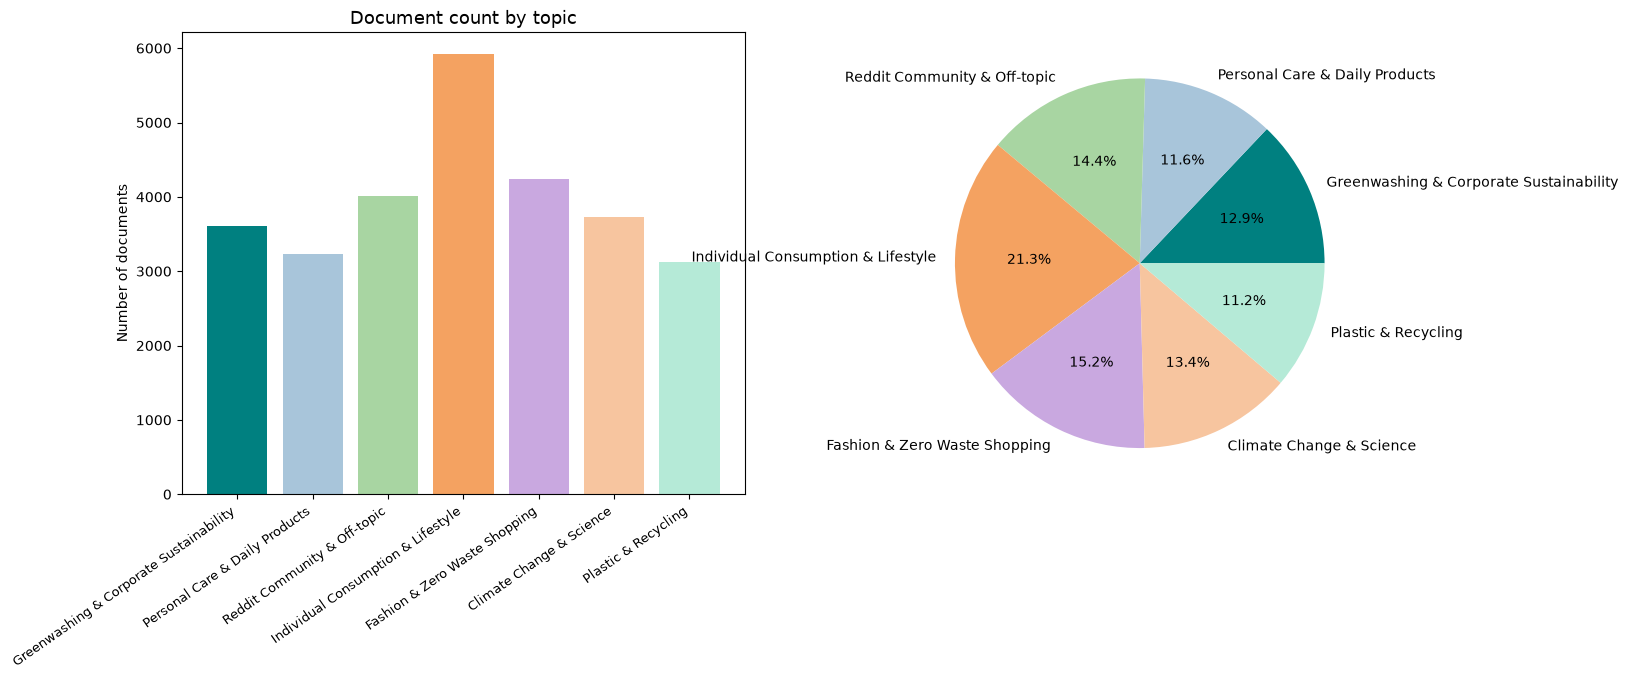

In [39]:
topic_labels = {
    1: 'Greenwashing & Corporate Sustainability',
    2: 'Personal Care & Daily Products',
    3: 'Reddit Community & Off-topic',
    4: 'Individual Consumption & Lifestyle',
    5: 'Fashion & Zero Waste Shopping',
    6: 'Climate Change & Science',
    7: 'Plastic & Recycling'
}

colors_palette = {
    1: 'teal',
    2: '#a8c5da',  # light blue
    3: '#a8d5a2',  # light green
    4: '#f4a261',  # light orange
    5: '#c9a8e0',  # light purple
    6: '#f7c59f',  # peach
    7: '#b5ead7'   # mint
}

topic_counts_labeled = topic_counts.rename(index=topic_labels)
colors_bar = [colors_palette[i] for i in topic_counts.index]
pie_colors = [colors_palette[i] for i in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- barplot ---
axes[0].bar(range(len(topic_counts)), topic_counts.values, color=colors_bar)
axes[0].set_xticks(range(len(topic_counts)))
axes[0].set_xticklabels(topic_labels.values(), rotation=35, ha='right', fontsize=9)
axes[0].set_title('Document count by topic', fontsize=13)
axes[0].set_ylabel('Number of documents')

# --- pie chart ---
axes[1].pie(
    topic_counts.values,
    labels=topic_labels.values(),
    autopct='%1.1f%%',
    colors=pie_colors)

In [30]:
df_greenwashing = df[df['dominant_topic'] == 1].copy()

print(f"Shape: {df_greenwashing.shape}")
print(f"Posts: {len(df_greenwashing[df_greenwashing['content_type']=='post'])}")
print(f"Comments: {len(df_greenwashing[df_greenwashing['content_type']=='comment'])}")

df_greenwashing.to_csv('../data/processed/df_greenwashing_topic1.csv', index=False)
print("✓ Saved!")

Shape: (3602, 10)
Posts: 272
Comments: 3330
✓ Saved!


In [31]:
keywords = (
    'sunscreen|sun screen|suncream|sun cream|sunblock|sun block|'
    'reef|coral|oxybenzone|octinoxate|reef-safe|'
    'banana boat|hawaiian tropic|stream2sea|'
    'spf|mineral sunscreen|chemical sunscreen'
)

mask = df_greenwashing['Text'].str.contains(keywords, case=False, na=False)

sunscreen_docs = df_greenwashing[mask]
print(f"Documents mentioning sunscreen/reef topics: {len(sunscreen_docs)}")
print(f"\nPosts: {len(sunscreen_docs[sunscreen_docs['content_type']=='post'])}")
print(f"Comments: {len(sunscreen_docs[sunscreen_docs['content_type']=='comment'])}")

print("\n--- Sample texts ---")
print(sunscreen_docs[['content_type', 'Text', 'subreddit']].head(10).to_string())

Documents mentioning sunscreen/reef topics: 8

Posts: 2
Comments: 6

--- Sample texts ---
      content_type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## 5. Second-Level LDA: Greenwashing Subset

LDA applied to the greenwashing subset only (n=3,602) to identify
internal sub-topics. This informs the stratified synthetic data
generation strategy in notebook 03.

In [40]:
df_greenwashing = pd.read_csv('../data/processed/df_greenwashing_topic1.csv', parse_dates=['Timestamp'])
print(f"Shape: {df_greenwashing.shape}")

Shape: (3602, 12)


In [41]:
df_greenwashing['text_clean'] = df_greenwashing['text_clean'].fillna('')

In [42]:
# max_features reduced to 2000 because the dataset is ~8x smaller (3,602 vs 27,849 documents)
# a vocabulary of 5000 on this subset would produce a very sparse matrix
# with many columns appearing in too few documents to carry meaningful signal for LDA
vectorizer_gw = CountVectorizer(
    max_features=2000,  # smaller vocabulary for smaller dataset
    min_df=3,           # lower threshold because dataset is smaller
    max_df=0.95
)

dtm_gw = vectorizer_gw.fit_transform(df_greenwashing['text_clean'])
print(f"Document-term matrix shape: {dtm_gw.shape}")

Document-term matrix shape: (3602, 2000)


In [43]:
# the greenwashing subset is more homogeneous than the full corpus
# start with n=4 and increase until topic quality plateaus
# n=6 selected for interpretability (see coherence score analysis below)
lda_gw = LatentDirichletAllocation(
    n_components=4,
    random_state=42,
    n_jobs=1
)

lda_gw.fit(dtm_gw)

feature_names_gw = vectorizer_gw.get_feature_names_out()

for i, topic in enumerate(lda_gw.components_):
    top_words = [feature_names_gw[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: company | product | consumer | sustainable | cost | business | emission | car | market | profit | buy | waste | sustainability | less | ev

Topic 2: company | money | climate | sustainability | change | job | business | fund | oil | year | industry | energy | government | big | green

Topic 3: energy | nuclear | power | fuel | carbon | solar | fossil | wind | gas | cost | technology | electricity | year | plant | emission

Topic 4: company | product | sustainable | greenwashing | brand | green | material | business | sustainability | environmental | plastic | claim | made | impact | fashion


In [44]:
# 5 topics trial
lda_gw = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    n_jobs=1
)

lda_gw.fit(dtm_gw)

# show top 15 words per topic
feature_names_gw = vectorizer_gw.get_feature_names_out()

for i, topic in enumerate(lda_gw.components_):
    top_words = [feature_names_gw[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: product | consumer | company | car | emission | cost | ev | buy | waste | sustainable | less | price | profit | vehicle | plastic

Topic 2: energy | company | carbon | fuel | fossil | money | fund | renewable | oil | year | green | investment | power | government | solar

Topic 3: energy | nuclear | power | fuel | solar | technology | gas | wind | cost | carbon | fossil | plant | battery | year | oil

Topic 4: product | sustainable | company | brand | greenwashing | green | material | plastic | environmental | sustainability | impact | claim | fashion | made | organic

Topic 5: company | business | sustainability | change | job | climate | money | industry | greenwashing | small | could | environmental | marketing | issue | project


In [45]:
# 6 topics trial
lda_gw = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    n_jobs=1
)

lda_gw.fit(dtm_gw)

# show top 15 words per topic
feature_names_gw = vectorizer_gw.get_feature_names_out()

for i, topic in enumerate(lda_gw.components_):
    top_words = [feature_names_gw[j] for j in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {i+1}: {' | '.join(top_words)}")


Topic 1: product | consumer | company | car | ev | emission | cost | buy | waste | less | sustainable | vehicle | profit | price | demand

Topic 2: energy | carbon | company | renewable | fund | money | emission | fuel | oil | fossil | government | climate | power | investment | electricity

Topic 3: nuclear | energy | power | fuel | solar | fossil | gas | technology | cost | wind | plant | carbon | battery | year | renewables

Topic 4: product | sustainable | company | brand | material | greenwashing | plastic | environmental | green | impact | fashion | claim | made | sustainability | process

Topic 5: company | business | sustainability | change | job | climate | small | could | greenwashing | industry | money | environmental | marketing | corporate | issue

Topic 6: green | greenwashing | sustainable | company | oil | money | market | new | year | example | efficiency | economy | energy | less | make


In [46]:
# assign dominant sub-topic to each document in the greenwashing subset
doc_topic_matrix_gw = lda_gw.transform(dtm_gw)
df_greenwashing['dominant_subtopic'] = doc_topic_matrix_gw.argmax(axis=1) + 1

subtopic_labels = {
    1: 'Consumer Products & EV',
    2: 'Energy Finance & Climate Policy',
    3: 'Energy Technologies',
    4: 'Greenwashing Claims & Sustainable Brands',
    5: 'Corporate Sustainability & Marketing',
    6: 'Green Economy & Greenwashing'
}

df_greenwashing['subtopic_label'] = df_greenwashing['dominant_subtopic'].map(subtopic_labels)

# count per subtopic
subtopic_counts = df_greenwashing['dominant_subtopic'].value_counts().sort_index()
print(subtopic_counts)

df_greenwashing.to_csv('../data/processed/df_greenwashing_topic1.csv', index=False)
print("✓ Saved!")

dominant_subtopic
1    650
2    381
3    726
4    573
5    842
6    430
Name: count, dtype: int64
✓ Saved!


### Coherence Score Analysis (gensim c_v)

### Greenwashing subset (n=3,602) - topics 2 to 8:

| n_topics | coherence |
|----------|-----------|
| 2 | 0.4996 |
| 3 | 0.4519 |
| 4 | 0.4684 |
| 5 | 0.4390 |
| 6 | 0.3775 |
| 7 | 0.4162 |
| 8 | 0.4364 |

**Decision: n_components = 6** - chosen for qualitative interpretability.
Coherence peaks at n=2 (0.4996) but two subtopics are too coarse
for meaningful downstream stratification. n=4 is the next local peak (0.4684),
but n=6 produces the clearest separation between greenwashing subtypes
(consumer products, energy finance, energy technologies, greenwashing claims,
corporate sustainability, green economy).

See `notebooks/02c_subset_coherence_score_colab.ipynb`.